# 01 - Exploración del Dataset
## TalentGuard: Sistema Inteligente para la Predicción del Riesgo de Rotación de Empleados

**Autor:** Nicolas Gomez  
**Programa:** Tecnología en Desarrollo de Software  
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Objetivo:** Exploración cualitativa del dataset para el Componente 3 del Proyecto Integrador

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Librerías cargadas")

Librerías cargadas


In [ ]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")

✅ Dataset cargado: 1470 filas × 35 columnas


## 1. Estructura del Dataset
Exploramos los tipos de variables, primeras filas y resumen general.

In [11]:
print("---- TIPOS DE VARIABLES ----")
print(df.dtypes)
print(f"\nVariables numéricas: {df.select_dtypes(include='number').shape[1]}")
print(f"Variables categóricas: {df.select_dtypes(include='object').shape[1]}")

---- TIPOS DE VARIABLES ----
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears  

/tmp/ipykernel_31375/76699084.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Variables categóricas: {df.select_dtypes(include='object').shape[1]}")


In [6]:
print("---- PRIMERAS 5 FILAS ----")
df.head()

---- PRIMERAS 5 FILAS ----


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
print("---- RESUMEN ESTADÍSTICO ----")
df.describe().round(2)

---- RESUMEN ESTADÍSTICO ----


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [15]:
print("---- Nulos y Registros Duplicados ----")
print("--- Nulos: \n")
print(df.isnull().sum())

print("--- Duplicados: \n")
print(df.duplicated().sum())

---- Nulos y Registros Duplicados ----
--- Nulos: 

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany    

In [14]:
print("---- Distribucion Objetivo -----")
print ( df [ "Attrition" ]. value_counts () )

---- Distribucion Objetivo -----
Attrition
No     1233
Yes     237
Name: count, dtype: int64


## 2. Calidad de los Datos
Sin valores nulos ni duplicados. Se identifican 3 columnas constantes sin valor analítico.

In [16]:
print("---- COLUMNAS CONSTANTES (sin variabilidad) ----")
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"  {col}: valor único = '{df[col].unique()[0]}'")
print("\nEstas columnas deben eliminarse antes del modelado.")

---- COLUMNAS CONSTANTES (sin variabilidad) ----
  EmployeeCount: valor único = '1'
  Over18: valor único = 'Y'
  StandardHours: valor único = '80'

Estas columnas deben eliminarse antes del modelado.


## 3. Variable Objetivo: Attrition
Análisis del desbalance de clases en la variable objetivo.

---- DISTRIBUCIÓN DE ATTRITION ----
  No: 1233 registros (83.9%)
  Yes: 237 registros (16.1%)


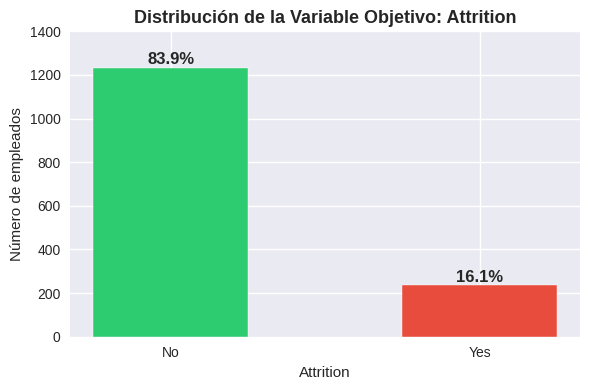

Gráfico guardado en docs/


In [17]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("---- DISTRIBUCIÓN DE ATTRITION ----")
for val in attrition_counts.index:
    print(f"  {val}: {attrition_counts[val]} registros ({attrition_pct[val]:.1f}%)")

# Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(attrition_counts.index, attrition_counts.values, 
              color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)

for bar, pct in zip(bars, attrition_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Distribución de la Variable Objetivo: Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Número de empleados')
ax.set_ylim(0, 1400)
plt.tight_layout()
plt.savefig('../docs/fig_attrition_distribucion.png', dpi=150)
plt.show()
print("Gráfico guardado en docs/")

## 4. Variables Clave
Análisis de las variables más relevantes para predecir la rotación.

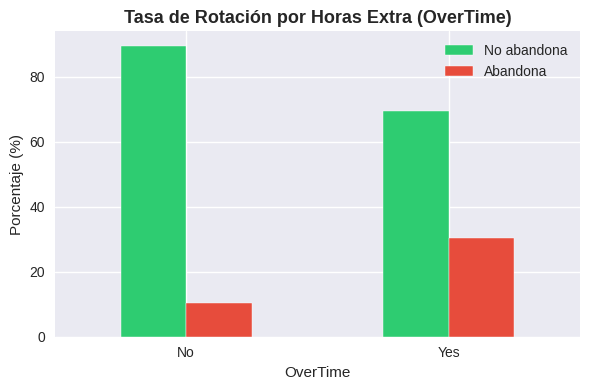

Gráfico guardado en docs/


In [18]:
overtime_attrition = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots(figsize=(6, 4))
overtime_attrition.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], 
                         edgecolor='white', width=0.5)

ax.set_title('Tasa de Rotación por Horas Extra (OverTime)', fontsize=13, fontweight='bold')
ax.set_xlabel('OverTime')
ax.set_ylabel('Porcentaje (%)')
ax.legend(['No abandona', 'Abandona'], loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../docs/fig_overtime_attrition.png', dpi=150)
plt.show()
print("Gráfico guardado en docs/")

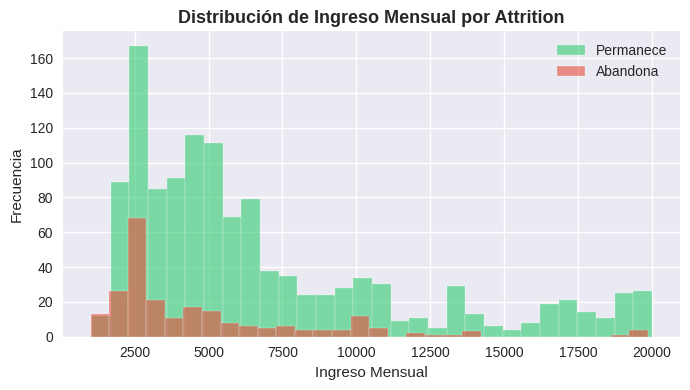

Gráfico guardado en docs/


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Attrition'] == label]['MonthlyIncome']
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')

ax.set_title('Distribución de Ingreso Mensual por Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Ingreso Mensual')
ax.set_ylabel('Frecuencia')
ax.legend(['Permanece', 'Abandona'])
plt.tight_layout()
plt.savefig('../docs/fig_income_attrition.png', dpi=150)
plt.show()
print("Gráfico guardado en docs/")

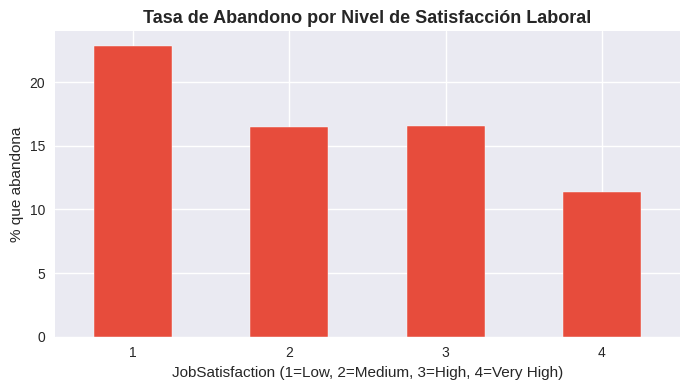

✅ Gráfico guardado en docs/


In [20]:
job_sat = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots(figsize=(7, 4))
job_sat['Yes'].plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white', width=0.5)

ax.set_title('Tasa de Abandono por Nivel de Satisfacción Laboral', fontsize=13, fontweight='bold')
ax.set_xlabel('JobSatisfaction (1=Low, 2=Medium, 3=High, 4=Very High)')
ax.set_ylabel('% que abandona')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../docs/fig_jobsatisfaction_attrition.png', dpi=150)
plt.show()
print("✅ Gráfico guardado en docs/")

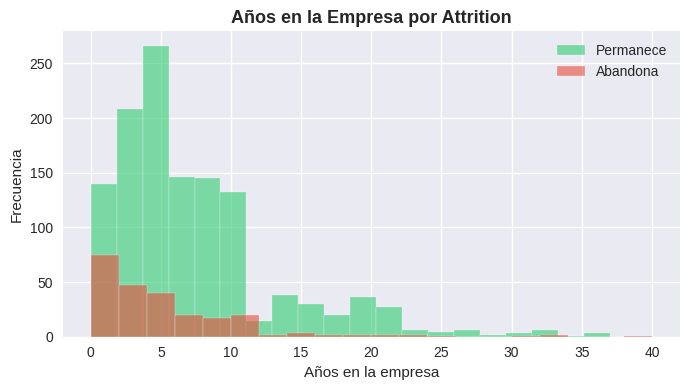

✅ Gráfico guardado en docs/


In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Attrition'] == label]['YearsAtCompany']
    ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')

ax.set_title('Años en la Empresa por Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Años en la empresa')
ax.set_ylabel('Frecuencia')
ax.legend(['Permanece', 'Abandona'])
plt.tight_layout()
plt.savefig('../docs/fig_years_attrition.png', dpi=150)
plt.show()
print("✅ Gráfico guardado en docs/")

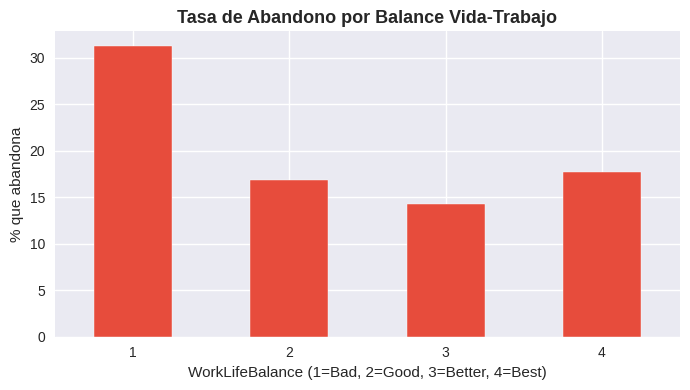

✅ Gráfico guardado en docs/


In [22]:
wlb = df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots(figsize=(7, 4))
wlb['Yes'].plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white', width=0.5)

ax.set_title('Tasa de Abandono por Balance Vida-Trabajo', fontsize=13, fontweight='bold')
ax.set_xlabel('WorkLifeBalance (1=Bad, 2=Good, 3=Better, 4=Best)')
ax.set_ylabel('% que abandona')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../docs/fig_worklife_attrition.png', dpi=150)
plt.show()
print("✅ Gráfico guardado en docs/")

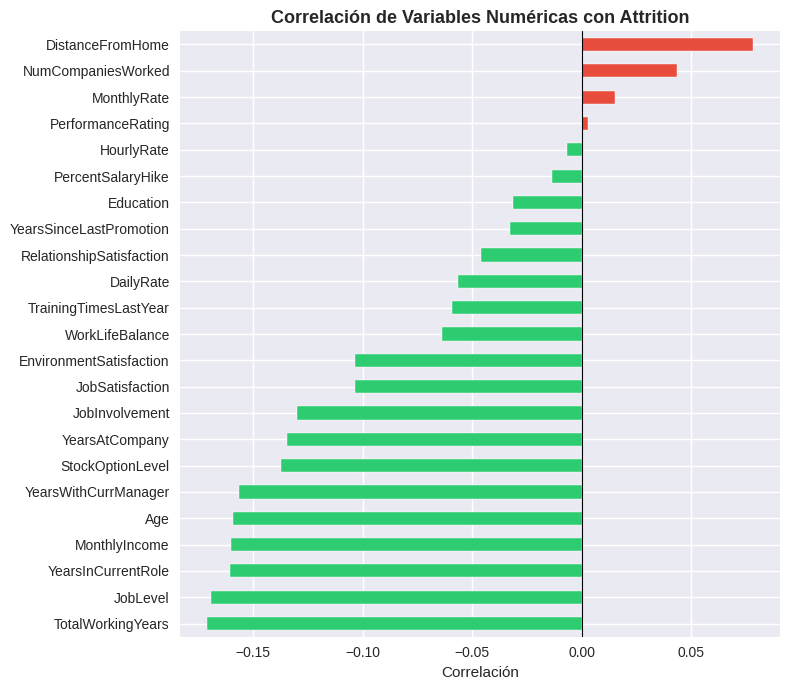

✅ Gráfico guardado en docs/


In [23]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
# Excluir columnas constantes
numeric_cols = [c for c in numeric_cols if c not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']]

# Agregar Attrition como numérica para la correlación
df_corr = df[numeric_cols].copy()
df_corr['Attrition_num'] = (df['Attrition'] == 'Yes').astype(int)

corr_with_attrition = df_corr.corr()['Attrition_num'].drop('Attrition_num').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_attrition.values]
corr_with_attrition.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Correlación de Variables Numéricas con Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../docs/fig_correlacion_attrition.png', dpi=150)
plt.show()
print("✅ Gráfico guardado en docs/")

## 5. Hallazgos Principales
Resumen de los patrones identificados en la exploración.

In [24]:
print("==== RESUMEN DE HALLAZGOS ====\n")

print("1. DESBALANCE DE CLASES:")
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
for val, pct in attrition_pct.items():
    print(f"   {val}: {pct:.1f}%")

print("\n2. OVERTIME vs ATTRITION:")
ot = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100
print(f"   Empleados SIN horas extra que abandonan: {ot.loc['No','Yes']:.1f}%")
print(f"   Empleados CON horas extra que abandonan: {ot.loc['Yes','Yes']:.1f}%")

print("\n3. INGRESO MENSUAL:")
print(f"   Mediana empleados que permanecen: ${df[df['Attrition']=='No']['MonthlyIncome'].median():,.0f}")
print(f"   Mediana empleados que abandonan:  ${df[df['Attrition']=='Yes']['MonthlyIncome'].median():,.0f}")

print("\n4. ANTIGÜEDAD:")
print(f"   Mediana años (permanece): {df[df['Attrition']=='No']['YearsAtCompany'].median():.0f} años")
print(f"   Mediana años (abandona):  {df[df['Attrition']=='Yes']['YearsAtCompany'].median():.0f} años")

print("\n5. SATISFACCIÓN LABORAL (% abandono por nivel):")
js = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack() * 100
for nivel, pct in js['Yes'].items():
    labels = {1:'Low', 2:'Medium', 3:'High', 4:'Very High'}
    print(f"   {labels[nivel]}: {pct:.1f}%")

print("\n6. COLUMNAS CONSTANTES A ELIMINAR:")
print("   EmployeeCount, Over18, StandardHours")

==== RESUMEN DE HALLAZGOS ====

1. DESBALANCE DE CLASES:
   No: 83.9%
   Yes: 16.1%

2. OVERTIME vs ATTRITION:
   Empleados SIN horas extra que abandonan: 10.4%
   Empleados CON horas extra que abandonan: 30.5%

3. INGRESO MENSUAL:
   Mediana empleados que permanecen: $5,204
   Mediana empleados que abandonan:  $3,202

4. ANTIGÜEDAD:
   Mediana años (permanece): 6 años
   Mediana años (abandona):  3 años

5. SATISFACCIÓN LABORAL (% abandono por nivel):
   Low: 22.8%
   Medium: 16.4%
   High: 16.5%
   Very High: 11.3%

6. COLUMNAS CONSTANTES A ELIMINAR:
   EmployeeCount, Over18, StandardHours
